# Transient heat equation on a U-shaped domain — AlphaPINN spectral PINN

**PDE:**  $\partial_t u - \kappa\,\Delta u = 0$  (heat / diffusion)

**Domain:**  $[0,2]\times[0,2]$ minus a notch $(x\in(0.6,1.4),\; y>0.8)$,  time $t\in[0,T]$

**Initial condition:**  $u(x,y,0) = 0$

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot, held for all $t$
- $u = 0$ everywhere else on the boundary — cold, held for all $t$

**Method:**  **AlphaPINN — global spectral PINN without Method of Lines.**

Since the Laplace eigenvectors $\Phi$ are global spatial modes, the full
space-time solution can be written as:

$$u(x,t) = \Phi\,\alpha(t), \quad \alpha(t) = \text{FNN}(t) \in \mathbb{R}^K$$

The FNN takes only $t$ as input and outputs the spectral expansion coefficients.
Time derivatives follow by autodiff; no state, no rollout, no BPTT.

Physics is enforced through the Galerkin weak-form residual:

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0 \quad \forall\,\phi\in V_h, \; t\in[0,T]$$

The IC $u(\cdot,0)=0$ is added as a Dirichlet BC on the $t=0$ face of the domain.


## 1. Imports & environment

In [ ]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ.setdefault("PINNS_BACKEND", "jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from collections import Counter

import pygmsh

import jax
import jax.numpy as jnp

from pinns import DomainMeshContinuous, DomainMeshDiscrete, AlphaPINN, LaplacianFeatures
from pinns import GNNMeshNetwork, GNNFeatures
from pinns import ReduceLROnPlateau, ExponentialDecay
from pinns.backends.jax import Trainer
from pinns.problem_weak import ProblemWeak

## 2. Build the U-shaped triangulated mesh

Mesh: 311 nodes, 532 triangles


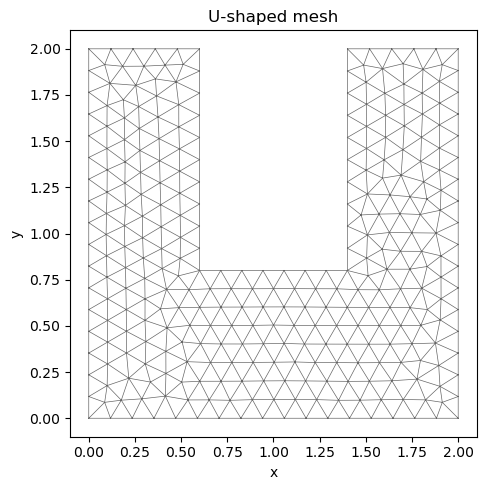

In [8]:
X_MAX    = 2.0
Y_MAX    = 2.0
NOTCH_X  = (0.6, 1.4)
NOTCH_Y  = 0.8
MESH_SIZE = 0.12

T_MAX    = 1.0    # total simulation time
KAPPA    = 0.05   # diffusion coefficient

def in_u_shape(pts: np.ndarray) -> np.ndarray:
    x, y   = pts[:, 0], pts[:, 1]
    in_box = (x >= 0) & (x <= X_MAX) & (y >= 0) & (y <= Y_MAX)
    in_cut = (x > NOTCH_X[0]) & (x < NOTCH_X[1]) & (y > NOTCH_Y)
    return in_box & ~in_cut

from pinns.meshes import u_shape as make_u_shape

verts, faces = make_u_shape(
    x_max=X_MAX, y_max=Y_MAX,
    notch_x=NOTCH_X, notch_y=NOTCH_Y,
    mesh_size=MESH_SIZE,
)
print(f"Mesh: {len(verts)} nodes, {len(faces)} triangles")

fig, ax = plt.subplots(figsize=(5, 5))
tri_vis = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_vis, "k-", lw=0.5, alpha=0.6)
ax.set_aspect("equal"); ax.set_title("U-shaped mesh")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()


## 3. Identify boundary nodes

Hot nodes  (u=1): 6
Cold nodes (u=0): 82
Interior nodes  : 223


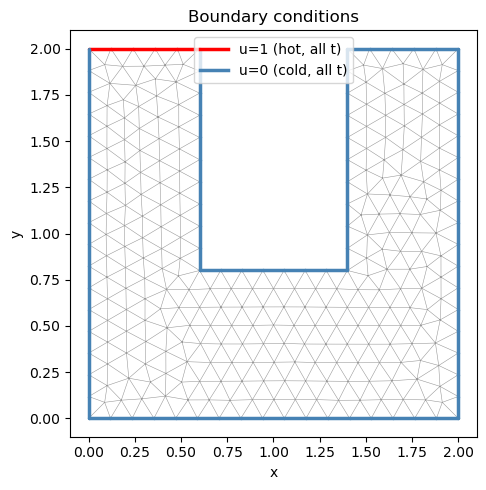

In [9]:
edge_count = Counter()
for tri_idx in faces:
    for i in range(3):
        e = tuple(sorted([tri_idx[i], tri_idx[(i + 1) % 3]]))
        edge_count[e] += 1

boundary_verts_idx = set()
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        boundary_verts_idx.update([v0, v1])
boundary_verts_idx = np.array(sorted(boundary_verts_idx))

is_boundary = np.zeros(len(verts), dtype=bool)
is_boundary[boundary_verts_idx] = True

tol    = MESH_SIZE / 2
is_hot = (verts[:, 1] >= Y_MAX - tol) & (verts[:, 0] <= NOTCH_X[0] + tol) & is_boundary

print(f"Hot nodes  (u=1): {is_hot.sum()}")
print(f"Cold nodes (u=0): {(is_boundary & ~is_hot).sum()}")
print(f"Interior nodes  : {(~is_boundary).sum()}")

from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(tri_vis, "k-", lw=0.4, alpha=0.4)
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        color = "red" if (is_hot[v0] and is_hot[v1]) else "steelblue"
        ax.plot([verts[v0, 0], verts[v1, 0]], [verts[v0, 1], verts[v1, 1]],
                color=color, lw=2.5, solid_capstyle="round")
ax.legend(handles=[
    Line2D([0],[0], color="red",       lw=2.5, label="u=1 (hot, all t)"),
    Line2D([0],[0], color="steelblue", lw=2.5, label="u=0 (cold, all t)"),
])
ax.set_aspect("equal"); ax.set_title("Boundary conditions")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

## 4. Finite-difference transient reference solution

Solve $\partial_t u = \kappa\,\Delta u$ with implicit Euler on a $100\times100$ regular grid.
The resulting space-time interpolant `fd_solution(x)` accepts columns $(x, y, t)$ and is
used by the trainer to log the relative L2 error at every checkpoint.

In [10]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

N_FD  = 100
xs_fd = np.linspace(0, X_MAX, N_FD + 1)
ys_fd = np.linspace(0, Y_MAX, N_FD + 1)
h_fd  = xs_fd[1] - xs_fd[0]
XX_fd, YY_fd = np.meshgrid(xs_fd, ys_fd, indexing='ij')

pts_flat = np.column_stack([XX_fd.ravel(), YY_fd.ravel()])
active   = in_u_shape(pts_flat).reshape(N_FD + 1, N_FD + 1)

node_id = np.full((N_FD + 1, N_FD + 1), -1, dtype=np.int64)
node_id[active] = np.arange(active.sum())
n_dof   = active.sum()
ii, jj  = np.where(active)

def _is_bnd(i, j):
    if not active[i, j]: return False
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i+di, j+dj
        if ni < 0 or ni > N_FD or nj < 0 or nj > N_FD or not active[ni, nj]:
            return True
    return False

bnd    = np.array([_is_bnd(i, j) for i, j in zip(ii, jj)])
hot    = bnd & (YY_fd[ii, jj] >= Y_MAX - h_fd/2) & (XX_fd[ii, jj] <= NOTCH_X[0] + h_fd/2)
bc_val = np.where(hot, 1.0, 0.0)

# Stiffness matrix (κ × 5-point Laplacian)
rows, cols, vals = [], [], []
for idx, (i, j) in enumerate(zip(ii, jj)):
    k = node_id[i, j]
    if bnd[idx]:
        rows.append(k); cols.append(k); vals.append(-1.0)
    else:
        rows.append(k); cols.append(k); vals.append(-KAPPA * 4.0 / h_fd**2)
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            nk = node_id[i+di, j+dj]
            rows.append(k); cols.append(nk); vals.append(KAPPA / h_fd**2)

A_mat = sp.csr_matrix((vals, (rows, cols)), shape=(n_dof, n_dof))

# N_TIME=500 → dt=0.002, giving <0.2% implicit-Euler temporal error.
# Keep N_TIME≥50× to ensure the FD reference is not the dominant error source
# when comparing against a ~4% PINN solution.
N_TIME = 500
dt_fd  = T_MAX / N_TIME
ts_fd  = np.linspace(0, T_MAX, N_TIME + 1)

M_diag = np.ones(n_dof); M_diag[bnd] = 0.0
M_mat  = sp.diags(M_diag / dt_fd, format='csr')
LHS    = M_mat - A_mat
b_bc   = np.zeros(n_dof); b_bc[bnd] = bc_val[bnd]

u_cur = np.zeros(n_dof)
u_cur[bnd] = bc_val[bnd]
LHS_lu = spla.splu(LHS.tocsc())

U_grid = np.full((N_TIME + 1, N_FD + 1, N_FD + 1), np.nan)
U_grid[0][active] = u_cur

for n_step in range(N_TIME):
    rhs = (M_mat @ u_cur) + b_bc
    rhs[bnd] = bc_val[bnd]
    u_cur = LHS_lu.solve(rhs)
    U_grid[n_step + 1][active] = u_cur

print(f"FD transient (κ={KAPPA}): {n_dof} DOFs × {N_TIME} steps  (dt={dt_fd:.4f})")
print(f"u range at t=T: [{np.nanmin(U_grid[-1]):.4f}, {np.nanmax(U_grid[-1]):.4f}]")

# ── Fill inactive cells (notch / outside bbox) with nearest-neighbour ────
U_grid_filled = U_grid.copy()
nan_mask_2d = ~active
_, nn_idx = distance_transform_edt(nan_mask_2d, return_indices=True)
for t_idx in range(N_TIME + 1):
    frame = U_grid_filled[t_idx]
    frame[nan_mask_2d] = frame[nn_idx[0][nan_mask_2d], nn_idx[1][nan_mask_2d]]

# ── Regular-grid space-time interpolator ─────────────────────────────────
_fd_rgi = RegularGridInterpolator(
    (ts_fd, xs_fd, ys_fd), U_grid_filled,
    method='linear', bounds_error=False, fill_value=np.nan,
)

def fd_solution(x: np.ndarray) -> np.ndarray:
    """Space-time FD reference: (n_pts, 3) cols (x,y,t) → (n_pts,1)."""
    txy    = x[:, [2, 0, 1]]
    vals   = _fd_rgi(txy).reshape(-1, 1)
    in_dom = in_u_shape(x[:, :2]).reshape(-1, 1)
    vals[~in_dom] = np.nan
    return vals

print("Regular-grid space-time interpolant ready.")


FD transient (κ=0.05): 7861 DOFs × 500 steps  (dt=0.0020)
u range at t=T: [-0.0000, 1.0000]
Regular-grid space-time interpolant ready.


## 5. Spatial domain & AlphaPINN spectral network

`DomainMeshContinuous` is used here: it signals that the network predicts
$u(x, t)$ **globally** over $[0, T]$ (not step-by-step).  `ProblemWeak`
assembles a continuous space-time weak form, sampling `n_time_points` random
time levels from $[0, T]$ each epoch.

The two typed subclasses of `DomainMesh` provide a clean API split:

| Class | Time model | `ProblemWeak` route |
|---|---|---|
| `DomainMeshContinuous` | continuous interval, random/quasi-random sampling | `make_loss_fn` — continuous space-time cubature |
| `DomainMeshDiscrete` | fixed `dt`, `n_steps` | `make_rollout_loss_fn` — implicit-Euler BPTT |

`t_sampling_method` options for `DomainMeshContinuous` (same API as `DomainCubic`):
`"uniform"` (default), `"midpoint"` (fixed grid), `"latin_hypercube"`, `"sobol"`, `"halton"`, or a callable.

`AlphaPINN` auto-detects the operational mode from the domain:
- **Continuous-time** (domain has `t_interval`, `use_state=False`): FNN takes $[\Phi(x),\, t]$ as input and outputs $u(x,t)$ directly — no state, no rollout, $\partial_t u$ by autodiff.
- **State-integrator** (`use_state=True`): $\Phi^\top u^n \to \Phi u^{n+1}$ — Method-of-Lines / BPTT.
- **Static** (no time, no state): steady-state solution.

`hidden_dims` gives full per-layer width control (like `FNN`): e.g. `[128, 128, 128, 128]`.


DomainMeshContinuous(2D × t∈[0.0, 1.0], sampling='uniform', n_time_points=20, n_nodes=311, n_conditions=3)


<Axes: title={'center': 't ∈ [0, 1]'}, xlabel='x', ylabel='y'>

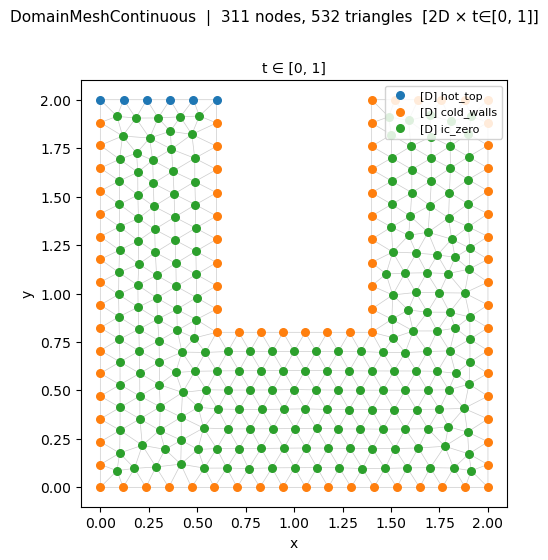

In [11]:
T_MAX    = 1.0    # total simulation time
KAPPA    = 0.05   # diffusion coefficient

# ── Space-time domain ────────────────────────────────────────────────────
domain = DomainMeshContinuous(
    (verts, faces),
    t_interval=[0.0, T_MAX],
    t_sampling_method="uniform",  # random per epoch (default)
    n_time_points=20,
)

# Spatial boundary conditions (held for all t).
# time_window defaults to [t_min, t_max] — active at every time.
domain.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)

# Initial condition u(x,y,0)=0 — pins interior nodes only at t=t_min.
# time_window=[t_min, t_min] is set automatically.
domain.add_initial_condition(value=0.0, name="ic_zero")
print(domain)

domain.plot()

## 6. PDE problem & AlphaPINN network

$$\int_\Omega \phi\,\partial_t u\,d\Omega + \kappa\int_\Omega \nabla u\cdot\nabla\phi\,d\Omega = 0$$

**Design:**  `ProblemWeak` is always defined **before** the network — it owns
the `output_transform` that enforces Dirichlet BCs and the IC ramp at every query point.
The network receives it as a constructor argument:

```python
problem = ProblemWeak(..., hard_constraints=["bc_name", ...])
net     = Network(domain, ..., output_transform=problem.output_transform)
```

This pattern is **identical** for continuous and state-integrator modes, and for
both `AlphaPINN` and `GNNMeshNetwork`.  In state-integrator mode the network also
clamps BC nodes internally before storing $u^{n+1}$ as the next $u^n$ (keeps rollout
stable), but that happens automatically — no extra argument required.

`AlphaPINN` is literally `LaplacianFeatures(domain, n_features) + FNN(hidden_dims)`:

| Component | Role |
|---|---|
| `LaplacianFeatures` | Maps `(x,y,t)` → `[Φ(x,y), t]` via barycentric interp of mesh eigenvectors |
| `FNN(hidden_dims)` | Standard MLP: `n_features` → `hidden_dims` → `n_outputs` |

No `n_time_steps`, no BPTT.  $\partial_t u$ comes from autodiff through the FNN w.r.t. the appended $t$ feature.


In [12]:
def volume_fn(x, y, params, phi, derivative=None):
    """Continuous transient weak form: ∫ φ ∂_t u dΩ + κ ∫ ∇u·∇φ dΩ"""
    kappa = params["fixed"]["kappa"]

    def phi_derivative(order):
        return derivative(phi, x, 0, order)

    du_dt = derivative(y, x, 0, (2,))              # ∂u/∂t  (autodiff through FNN)
    du_dx = derivative(y, x, 0, (0,))              # ∂u/∂x
    du_dy = derivative(y, x, 0, (1,))              # ∂u/∂y
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)   # (n_pts, 2)  — spatial only

    dphi_dx = derivative(phi, x, 0, (0,))
    dphi_dy = derivative(phi, x, 0, (1,))
    grad_phi = jnp.stack([dphi_dx, dphi_dy], axis=-1)

    return phi * du_dt + kappa * jnp.sum(grad_u * grad_phi, axis=-1)

# ── PDE problem ───────────────────────────────────────────────────────────
# ic_transition controls how the hard IC is factorised:
#   "tanh"   (default):  u = u_IC + tanh(t-t_min) · NN    ← saturates at 0.76 for T=1!
#   "linear"           :  u = u_IC + (t-t_min)    · NN    ← fully lifted at t=T
#   lambda t: t*(2-t)  :  quadratic ramp, also fully lifted
#
# "linear" is the classic & safest choice: the IC u=0 means
#   u(x,t) = t · NN(x,t), so NN directly learns du/dt at t=0 from the PDE.
problem = ProblemWeak(
    domain         = domain,
    volume_fn      = volume_fn,
    params         = {"kappa": float(KAPPA)},
    input_names    = ["x", "y", "t"],
    output_names   = ["u"],
    cubature_order = 4,
    lagrange_multipliers=["pde", "ic_zero"],
    hard_constraints = ["hot_top", "cold_walls"],
    ic_transition  = "linear",        # u = t · NN  — fully lifted at t=T=1
    solution       = fd_solution,     # FD reference — enables true/error panels
)
problem.show_problem()

# ── AlphaPINN spectral network ────────────────────────────────────────────
net = AlphaPINN(
    domain,
    n_features       = 128,
    hidden_dims      = [128, 128, 128, 128],
    n_outputs        = 1,
    activation       = 'tanh',
    output_transform = problem.output_transform,
)

<IPython.core.display.Math object>

LaplacianFeatures: computing 127 Laplace eigenvectors for mesh with 311 nodes … done.


## 7. Training

Standard PINN training — no curriculum, no BPTT.  The full space-time loss:

$$\mathcal{L}(\theta) = \|\mathcal{R}(u_\theta)\|^2 + \lambda_\text{BC}\|\text{BCs}\|^2 + \lambda_\text{IC}\|u_\theta(\cdot,0)\|^2$$

is minimised in one shot.


In [13]:
trainer = Trainer(problem, net)
trainer.compile(
    learning_rate    = 1e-3,
    lagrange_lr      = 1e-3,
    epochs           = 10_000,
    print_each       = 500,
    show_plots       = True,
    plot_time_points = [0.0, 0.5, 1.0],
    weights = {
        "pde":    1.0,
        "ic_zero": 1.0,   # soft: must compete with PDE loss
        # hot_top / cold_walls are hard-constrained → auto-filled with 0.0
    },
)
# trainer.train()


---

## Part B — AlphaPINN state-integrator (MoL / BPTT)

An alternative formulation that replaces the continuous space-time FNN with a
**learned one-step time integrator** in spectral space.

**Architecture** at each time step $n$:

$$\alpha^n = \Phi^\top u^n \quad\xrightarrow{\text{MLP + skip}}\quad \alpha^{n+1} = \alpha^n + \text{MLP}(\alpha^n) \quad\xrightarrow{\,\Phi\,}\quad u^{n+1}$$

The **residual (skip) connection** means the MLP learns only the increment $\Delta\alpha^n$.
Each BPTT Jacobian factor becomes $I + J_\text{MLP}$ instead of $J_\text{MLP}$, keeping
gradients from vanishing through long rollout chains.

| Step | Cost |
|---|---|
| Encode $\alpha^n = \Phi^\top u^n$ | $O(N_h \cdot K)$ — one mat-vec |
| Advance $\alpha^{n+1} = \alpha^n + \text{MLP}(\alpha^n)$ | $O(K \cdot d_\text{hidden})$ — tiny |
| Decode $u^{n+1} = \Phi\,\alpha^{n+1}$ | $O(N_h \cdot K)$ — one mat-vec |

With $K=64$ modes and $N_h \approx 500$ nodes this is **~100–1000× cheaper** per
forward pass than the GNN variant.

The implicit-Euler weak-form residual:

$$\int_\Omega \phi\,\frac{u^{n+1} - u^n}{\Delta t}\,d\Omega
+ \kappa\int_\Omega \nabla u^{n+1}\cdot\nabla\phi\,d\Omega = 0$$

is minimised end-to-end over all time steps via BPTT (`jax.lax.scan`).

**Same API pattern as Part A** — `problem_b` is defined first, then `net_b` receives
`output_transform=problem_b.output_transform`.  In state-integrator mode the network
also clamps BC nodes internally (automatically) before storing $u^{n+1}$ as the next
$u^n$ — essential for rollout stability but requires no extra argument.


### B1. Spatial domain


In [14]:
N_TIME_B = 20
ts_b     = np.linspace(0.0, T_MAX, N_TIME_B + 1)   # [t_0, t_1, ..., t_N]
dt_b     = ts_b[1] - ts_b[0]

# ── Purely spatial domain with discrete time axis ─────────────────────────
domain_b = DomainMeshDiscrete((verts, faces), time_points=ts_b)

domain_b.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain_b.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)
domain_b.add_initial_condition(value=0.0, name="ic_zero")

print(domain_b)


DomainMeshDiscrete(2D, dt=0.05, n_steps=20, t∈[0.0, 1.0], n_nodes=311, n_conditions=3)


### B2. PDE problem & AlphaPINN network


In [15]:
def volume_fn_b(x, y, params, phi, derivative=None):
    """Implicit-Euler MoL weak form: ∫ φ (u^{n+1}-u^n)/dt dΩ + κ ∫ ∇u^{n+1}·∇φ dΩ = 0"""
    u_prev      = params["internal"]["u_prev"]
    grad_u_prev = params["internal"]["grad_u_prev"]
    dt          = params["internal"]["dt"]
    kappa       = params["fixed"]["kappa"]

    du_dx = derivative(y, x, 0, (0,))
    du_dy = derivative(y, x, 0, (1,))
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)

    dphi_dx = derivative(phi, x, 0, (0,))
    dphi_dy = derivative(phi, x, 0, (1,))
    grad_phi = jnp.stack([dphi_dx, dphi_dy], axis=-1)

    return phi * (y[:, 0] - u_prev) / dt + kappa * jnp.sum(grad_u * grad_phi, axis=-1)

# ── Problem FIRST — owns hard-constraint output_transform ─────────────────
problem_b = ProblemWeak(
    domain         = domain_b,
    volume_fn      = volume_fn_b,
    params         = {"kappa": float(KAPPA)},
    input_names    = ["x", "y", "t"],
    output_names   = ["u"],
    lagrange_multipliers = ["pde"],
    hard_constraints = ["hot_top", "cold_walls"],
    cubature_order = 4,
    solution       = fd_solution,
)
problem_b.show_problem()

# ── AlphaPINN state-integrator ────────────────────────────────────────────
# Node-level BC clamping is automatic (always applied before state is stored).
# output_transform enforces BCs at query points — consistent with Part A.
net_b = AlphaPINN(
    domain_b,
    n_features       = 256,
    hidden_dims      = [256, 256, 256, 256],
    n_outputs        = 1,
    activation       = 'tanh',
    residual         = True,
    normalize_input  = True,
    output_transform = problem_b.output_transform,
)
print(net_b)


<IPython.core.display.Math object>

AlphaPINN (state-integrator): computing 256 Laplace eigenvectors for mesh with 311 nodes … 

done.
AlphaPINN(n_nodes=311, n_eigenvectors=256, hidden_dims=[256, 256, 256, 256], n_outputs=1, mode='state-integrator')


### B3. BPTT rollout training

In [16]:
trainer_b = Trainer(problem_b, net_b)
trainer_b.compile(
    optimizer           = "soap",   # SOAP: second-order-ish, faster convergence than Adam
    learning_rate       = 1e-3,
    lagrange_lr         = 0,
    lr_scheduler        = ReduceLROnPlateau(window=500, epsilon=1e-3, factor=0.5, min_lr=1e-6),
    epochs_by_time_step = 500,
    epochs              = 3_000,
    print_each          = 500,
    show_plots          = True,
    plot_time_points    = [0.1, 0.5, 1.0],
    grad_clip           = 1.0,
)
# trainer_b.train()

---

## Part C — GNNMeshNetwork continuous mode

Replaces AlphaPINN's spectral basis with a **trainable Graph Neural Network** that runs
on the fixed triangular mesh.  The architecture mirrors Part A exactly — the only
substitution is `AlphaPINN` → `GNNMeshNetwork(domain_c)` where `domain_c` is a
`DomainMeshContinuous`:

$$\underbrace{[x,y]_\text{nodes}}_{\text{node feats}} \xrightarrow{\text{GNN encoder (ChebConv} \times K)} (n_\text{nodes},\,d_\text{hidden}) \xrightarrow{\text{bary-interp}} (n_\text{query},\,d_\text{hidden}) \xrightarrow{[\ \cdot\ ,\,t\ ]} \xrightarrow{\text{MLP}} (n_\text{query},\,1)$$

Time enters **after** interpolation, so `∂u/∂t` is taken by clean autodiff through the MLP w.r.t. the appended `t` feature.


### C1. Space-time domain & GNNMeshNetwork (continuous)


In [17]:
N_TIME_C = 20
ts_c     = np.linspace(0.0, T_MAX, N_TIME_C + 1)

# ── Space-time continuous domain ──────────────────────────────────────────
domain_c = DomainMeshContinuous((verts, faces), t_interval=(0.0, T_MAX))

domain_c.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain_c.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)

domain_c.add_initial_condition(value=0.0, name="ic_zero")

print(domain_c)


DomainMeshContinuous(2D × t∈[0.0, 1.0], sampling='uniform', n_time_points=10, n_nodes=311, n_conditions=3)


### C2. PDE problem — heat equation weak form (space-time)


In [18]:
def volume_fn_c(x, y, params, phi, derivative=None):
    """Space-time weak form: ∫ φ ∂u/∂t dΩ + κ ∫ ∇u · ∇φ dΩ = 0"""
    kappa = params["fixed"]["kappa"]

    du_dt = derivative(y, x, 0, (2,))
    du_dx = derivative(y, x, 0, (0,))
    du_dy = derivative(y, x, 0, (1,))

    dphi_dx = derivative(phi, x, 0, (0,))
    dphi_dy = derivative(phi, x, 0, (1,))

    return phi * du_dt + kappa * (du_dx * dphi_dx + du_dy * dphi_dy)

# ── Problem FIRST — same pattern as Part A ────────────────────────────────
problem_c = ProblemWeak(
    domain           = domain_c,
    volume_fn        = volume_fn_c,
    params           = {"kappa": float(KAPPA)},
    input_names      = ["x", "y", "t"],
    output_names     = ["u"],
    lagrange_multipliers = ["pde", "ic_zero"],
    hard_constraints = ["hot_top", "cold_walls"],
    ic_transition    = "linear",
    cubature_order   = 4,
    solution         = fd_solution,
)
problem_c.show_problem()

# ── GNNMeshNetwork (continuous mode) ─────────────────────────────────────
# output_transform from problem_c enforces BCs + IC exactly — no node clamping needed.
net_c = GNNMeshNetwork(
    domain_c,
    hidden_dim       = 64,
    poly_order       = 10,
    message_steps    = 4,
    n_outputs        = 1,
    decoder_dims     = (128, 128),
    activation       = 'tanh',
    decoder_act      = 'tanh',
    output_transform = problem_c.output_transform,
)
print(net_c)


<IPython.core.display.Math object>

GNNMeshNetwork(continuous, n_nodes=311, hidden_dim=64, poly_order=10, message_steps=4+MLP[128, 128], n_outputs=1)


### C3. Training


In [19]:
trainer_c = Trainer(problem_c, net_c)
trainer_c.compile(
    learning_rate    = 1e-3,
    lagrange_lr      = 1e-3,
    epochs           = 10_000,
    print_each       = 500,
    show_plots       = True,
    plot_time_points = [0.0, 0.5, 1.0],
    weights = {
        "pde":    1.0,
        "ic_zero": 1.0,   # soft: must compete with PDE loss
        # hot_top / cold_walls are hard-constrained → auto-filled with 0.0
    },
)
# trainer_c.train()


---

## Part D — GNNMeshNetwork state-integrator (BPTT rollout)

Mirrors Part B but uses `GNNMeshNetwork(domain_d, residual=True)` with a `DomainMeshDiscrete`, which
auto-triggers **state-integrator mode**.

**Architecture** at each time step $n$ (with `residual=True`):

$$\underbrace{[x,y,\,u^n]_\text{nodes}}_{\text{node feats}}\xrightarrow{\text{GNN encoder (ChebConv} \times K)} (n_\text{nodes},\,d_\text{hidden})\xrightarrow{\text{MLP (per node)}} \Delta u^n \xrightarrow{+\,u^n} u^{n+1}_\text{nodes}\xrightarrow{\text{bary-interp}} u^{n+1}(\mathbf{x})$$

The **residual/skip connection** (`u^{n+1} = u^n + GNN(u^n)`) mirrors AlphaPINN's
`α^{n+1} = α^n + MLP(α^n)`.  Without it the GNN must learn the full identity
mapping, which tends to collapse to the steady-state solution (satisfying BCs but
ignoring the transient from the IC).

BC nodes are **clamped automatically** after each rollout step (internal to the network,
no user argument needed) to keep the state stable across long rollouts.  Query-point
enforcement uses `output_transform=problem_d.output_transform`.


### D1. Spatial domain & GNNMeshNetwork (state-integrator)


In [20]:
N_TIME_D = 20
ts_d     = np.linspace(0.0, T_MAX, N_TIME_D + 1)
dt_d     = ts_d[1] - ts_d[0]

# ── Purely spatial domain with discrete time axis ─────────────────────────
# GNNMeshNetwork auto-detects DomainMeshDiscrete → state-integrator mode.
domain_d = DomainMeshDiscrete((verts, faces), time_points=ts_d)

domain_d.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain_d.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)

domain_d.add_initial_condition(value=0.0, name="ic_zero")

print(domain_d)


DomainMeshDiscrete(2D, dt=0.05, n_steps=20, t∈[0.0, 1.0], n_nodes=311, n_conditions=3)


### D2. PDE problem — implicit-Euler weak form (MoL)


In [ ]:
def volume_fn_d(x, y, params, phi, derivative=None):
    """Implicit-Euler MoL weak form (same as Part B):
    ∫ φ (u^{n+1}-u^n)/dt dΩ  +  κ ∫ ∇u^{n+1}·∇φ dΩ = 0
    """
    u_prev = params["internal"]["u_prev"]
    dt     = params["internal"]["dt"]
    kappa  = params["fixed"]["kappa"]

    du_dx = derivative(y, x, 0, (0,))
    du_dy = derivative(y, x, 0, (1,))

    dphi_dx = derivative(phi, x, 0, (0,))
    dphi_dy = derivative(phi, x, 0, (1,))

    return phi * (y[:, 0] - u_prev) / dt + kappa * (du_dx * dphi_dx + du_dy * dphi_dy)

# ── Problem FIRST — owns hard-constraint output_transform ─────────────────
problem_d = ProblemWeak(
    domain         = domain_d,
    volume_fn      = volume_fn_d,
    params         = {"kappa": float(KAPPA)},
    input_names    = ["x", "y", "t"],
    output_names   = ["u"],
    lagrange_multipliers = ["pde"],
    hard_constraints = ["hot_top", "cold_walls"],
    cubature_order = 4,
    solution       = fd_solution,
)
problem_d.show_problem()

# ── GNNMeshNetwork (state-integrator mode) ────────────────────────────────
# DomainMeshDiscrete → use_state=True detected automatically.
# residual=True: the GNN predicts Δu^n rather than u^{n+1} directly,
#   i.e. u^{n+1} = u^n + GNN(u^n).  This mirrors AlphaPINN's skip connection
#   (α^{n+1} = α^n + MLP(α^n)) and prevents collapse to the steady-state solution.
# Node-level BC clamping is applied automatically after each rollout step.
net_d = GNNMeshNetwork(
    domain_d,
    hidden_dim       = 64,
    poly_order       = 2,
    message_steps    = 4,
    n_outputs        = 1,
    decoder_dims     = (256, 256),
    activation       = 'tanh',
    decoder_act      = 'tanh',
    residual         = True,
    output_transform = problem_d.output_transform,
)
print(net_d)


<IPython.core.display.Math object>

GNNMeshNetwork(state-integrator, n_nodes=311, hidden_dim=54, poly_order=2, message_steps=4+MLP[256, 256], n_outputs=1, residual=True)


### D3. BPTT rollout training


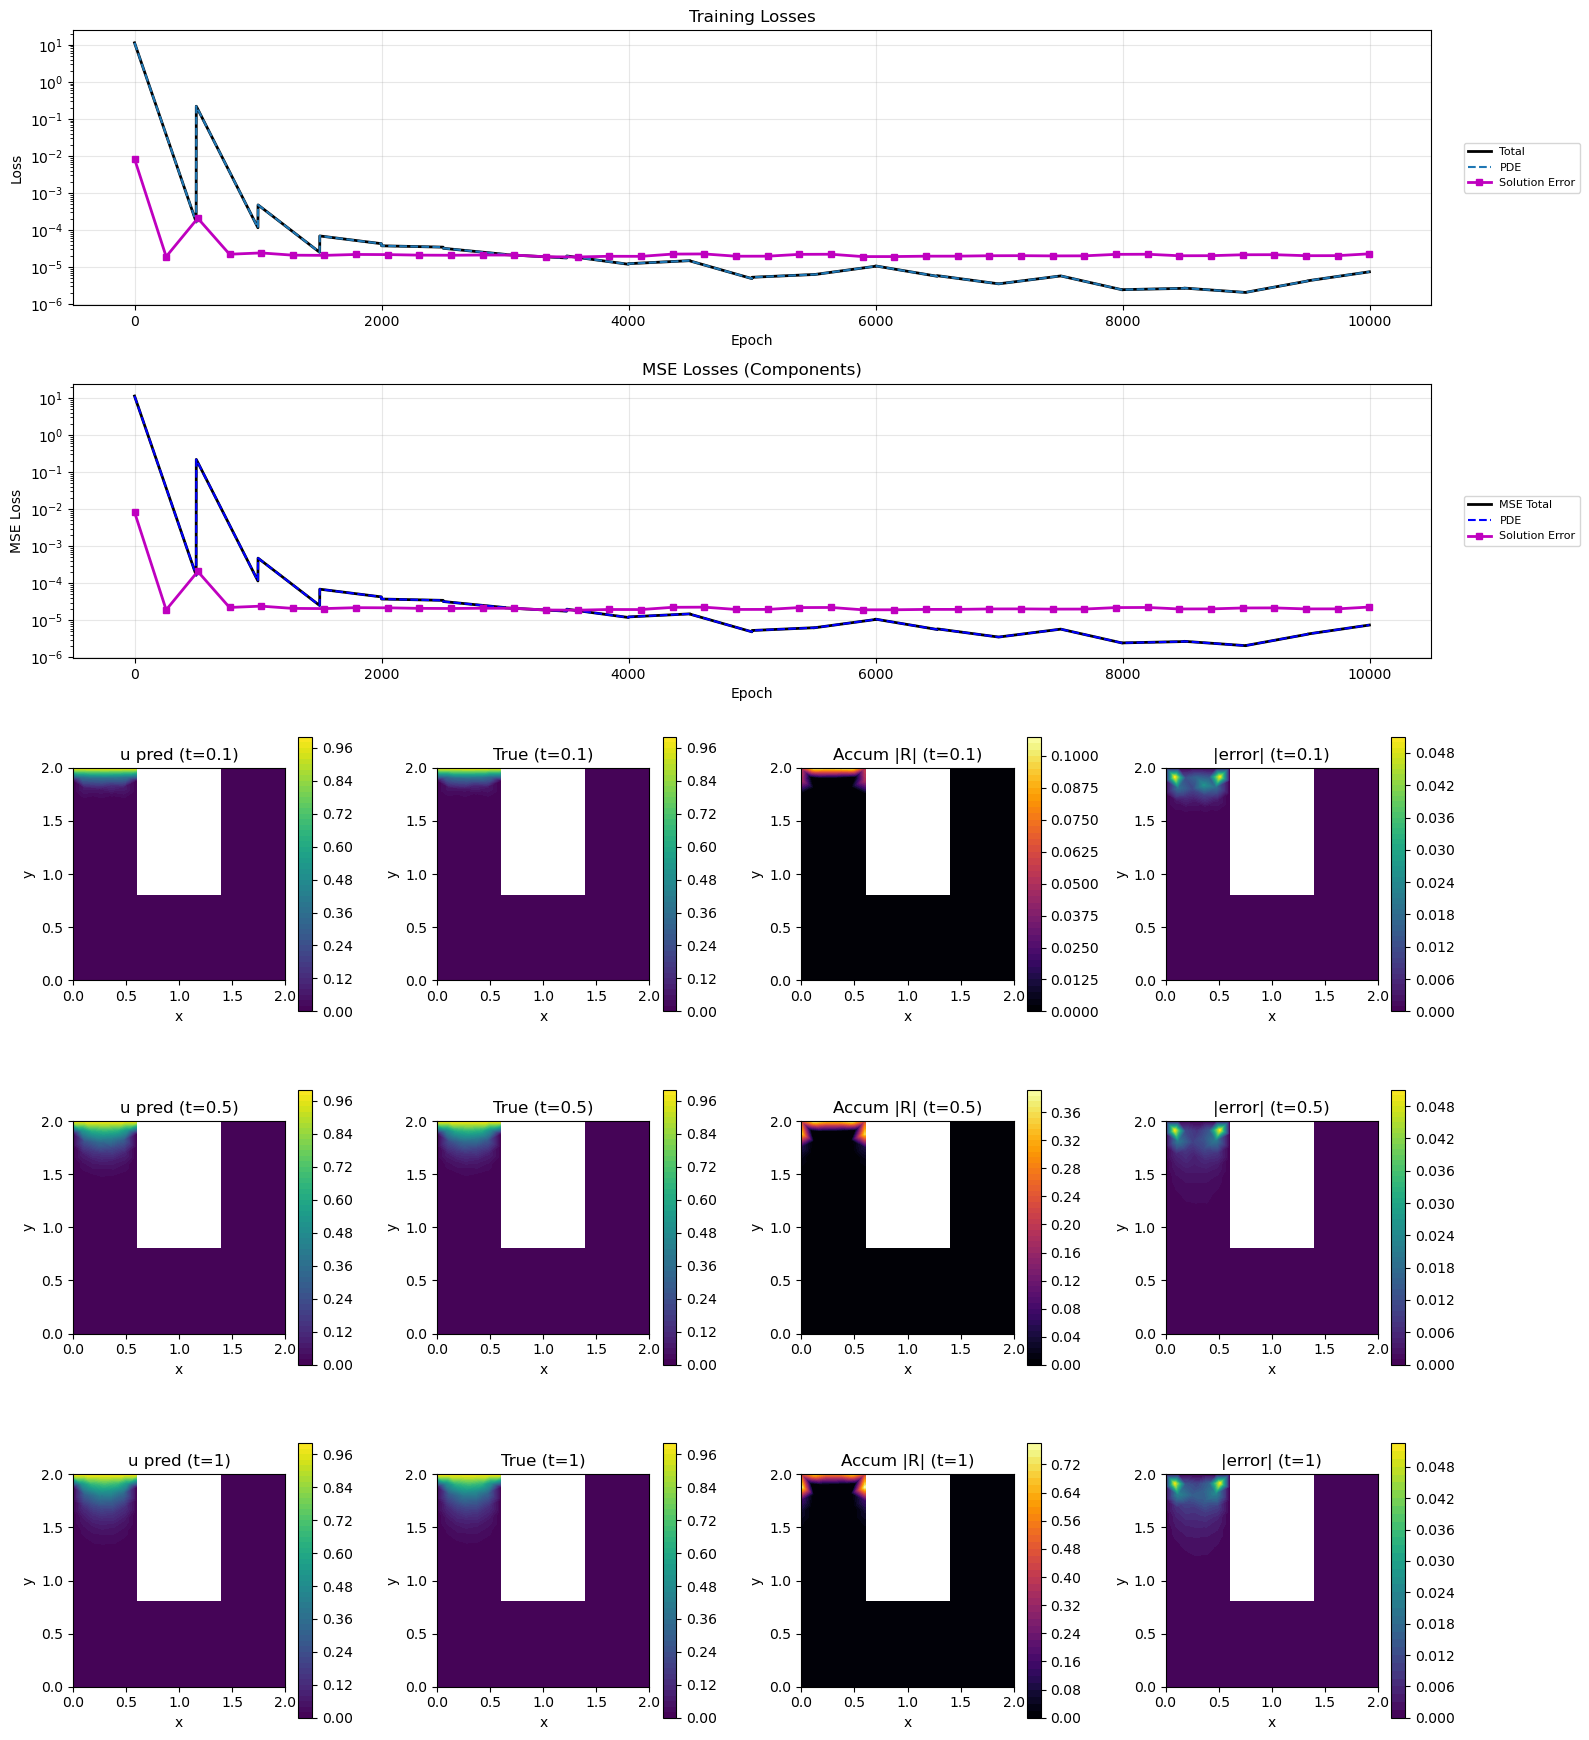

Stage 1/20 | Epoch 0/10000 | Loss: 1.13e+01 | MSE Loss: 1.13e+01 | PDE: 1.13e+01 | BCs: [] | Time: 0.0s | Error: 8.29e-03
Stage 1/20 | Epoch 500/10000 | Loss: 1.64e-04 | MSE Loss: 1.64e-04 | PDE: 1.64e-04 | BCs: [] | Time: 12.8s | Error: 1.91e-05
Stage 2/20 | Epoch 500/10000 | Loss: 2.19e-01 | MSE Loss: 2.19e-01 | PDE: 2.19e-01 | BCs: [] | Time: 0.0s | Error: 2.08e-04
Stage 2/20 | Epoch 1000/10000 | Loss: 1.15e-04 | MSE Loss: 1.15e-04 | PDE: 1.15e-04 | BCs: [] | Time: 13.7s | Error: 2.22e-05
Stage 3/20 | Epoch 1000/10000 | Loss: 4.76e-04 | MSE Loss: 4.76e-04 | PDE: 4.76e-04 | BCs: [] | Time: 0.0s | Error: 2.41e-05
Stage 3/20 | Epoch 1500/10000 | Loss: 2.50e-05 | MSE Loss: 2.50e-05 | PDE: 2.50e-05 | BCs: [] | Time: 15.3s | Error: 2.09e-05
Stage 4/20 | Epoch 1500/10000 | Loss: 6.92e-05 | MSE Loss: 6.92e-05 | PDE: 6.92e-05 | BCs: [] | Time: 0.0s | Error: 2.07e-05
Stage 4/20 | Epoch 2000/10000 | Loss: 4.28e-05 | MSE Loss: 4.28e-05 | PDE: 4.28e-05 | BCs: [] | Time: 16.4s | Error: 2.19e-05
S

In [22]:
trainer_d = Trainer(problem_d, net_d)
trainer_d.compile(
    optimizer           = "soap",
    learning_rate       = 1e-3,
    lagrange_lr         = 0,
    lr_scheduler        = ReduceLROnPlateau(window=500, epsilon=1e-3, factor=0.5, min_lr=1e-6),
    epochs_by_time_step = 500,
    epochs              = 3_000,
    print_each          = 500,
    show_plots          = True,
    plot_time_points    = [0.1, 0.5, 1.0],
    grad_clip           = 1.0,
)
trainer_d.train()